# Network Integration with STARLIB rates

STARLIB is a library of thermonuclear reaction rates and weak laboratory interaction rates tabulated as a function of temperature. Its key distinction from other sources is that it provides factor uncertainties for each tabulated rate. Here, we elaborate upon its current implementation within pynucastro and provide examples to illustrate its usage.

In [1]:
import pynucastro as pyna

The intended way to access StarLib rates in pynucastro is through a {py:obj}`StarLibLibrary <pynucastro.rates.library.StarLibLibrary>`. When an instance of `StarLibLibrary` is created without an argument, it returns a {py:obj}`Library <pynucastro.rates.library.Library>` holding instances of {py:obj}`StarLibRate <pynucastro.rates.starlib_rate>` at their respective median values, i.e., no sampling is performed.

In [2]:
sl_m = pyna.StarLibLibrary()

To enable sampling, we must pass a seed. This seed can be an integer of an array of integers. Here, we create several sampled libraries with arbitrarily fixed seeds to ensure reproducibility.

In [ ]:
seeds = [123, 456, 789, [123, 456],
         246, 680, 135, [246, 680]]
sampled_libs = [pyna.StarLibLibrary(seed=s) for s in seeds]
n_sampled = len(sampled_libs)

## Writing and Integrating Networks with sampled rates

In [4]:
import numpy as np
from scipy.integrate import solve_ivp

Having created sampled libraries, we can then explore integrating reaction networks with such sampled libraries and compare obtained results against unsampled `StarLiblibrary` and {py:obj}`ReacLibLibrary <pynucastro.rates.library.ReacLibLibrary>`

In [5]:
rl = pyna.ReacLibLibrary()

To be consistent with previous examples, we look at a basic CNO network.

In [6]:
nuclei =  ["p", "he4", "c12", "c13", "n13",
         "n14", "n15", "o14", "o15" ]

rr_lib = rl.linking_nuclei(nuclei)
sm_lib = sl_m.linking_nuclei(nuclei)

sampled_rates_list = []

for lib in sampled_libs:
    sampled_rates_list.append(lib.linking_nuclei(nuclei))

In [7]:
rrnet = pyna.PythonNetwork(libraries=rr_lib)
rrnet.write_network("rrnet.py")

smnet = pyna.PythonNetwork(libraries=sm_lib)
smnet.write_network("smnet.py")

for i, lib in enumerate(sampled_rates_list):
    net = pyna.PythonNetwork(libraries=lib)
    net.write_network(f"s{i}net.py")

Since the sampled networks are indexed, importing them can be handled in a scalable manner through the `importlib` package.

In [8]:
import importlib

import rrnet
import smnet

snets = {}
for i in range(n_sampled):
    name = f"s{i}net"
    module = importlib.import_module(name)
    snets[name] = importlib.reload(module)

The thermodynamic conditions and composition are initialized similar to previous examples.

In [9]:
rho = 150
T = 1.5e7

X0 = np.zeros(rrnet.nnuc)
X0[rrnet.jp] = 0.7
X0[rrnet.jhe4] = 0.28
X0[rrnet.jc12] = 0.02

Y0 = X0/rrnet.A

We are then ready to integrate.

In [10]:
tmax = 1.e20

rrsol = solve_ivp(rrnet.rhs, [0, tmax], Y0, method="BDF", jac=rrnet.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-6)
smsol = solve_ivp(smnet.rhs, [0, tmax], Y0, method="BDF", jac=smnet.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-6)

ssols = []
for i in range(n_sampled):
    sol = solve_ivp(snets[f's{i}net'].rhs, [0, tmax], Y0, method="BDF",
                    jac=snets[f's{i}net'].jacobian, dense_output=True, args=(rho, T), 
                    rtol=1.e-6, atol=1.e-6)
    ssols.append(sol)

## Plotting Results

In [11]:
import matplotlib.pyplot as plt

Given that we are comparing network integration across three kinds of rates: sampled STARLIB rates, median STARLIB rates and ReacLib rates, we can setup a color map to best visualize mass fractions over time.

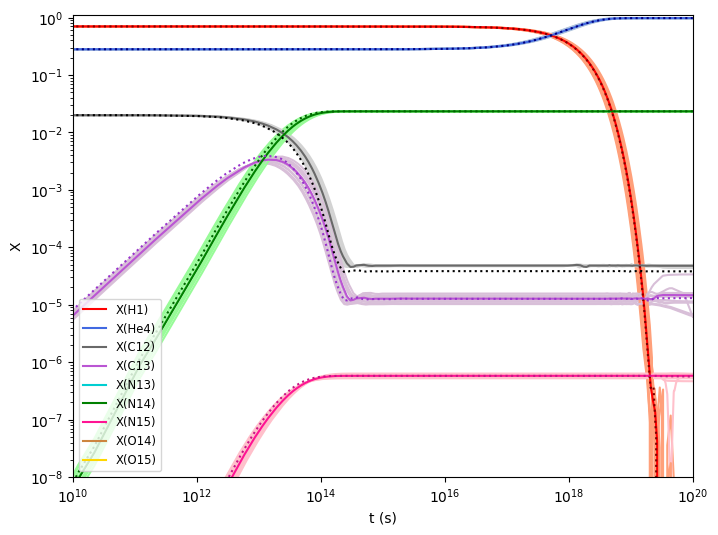

: 

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

col_map_light = {'H1':'lightsalmon', 'He4':'lightsteelblue',
                 'C12': 'lightgray', 'C13': 'thistle',
                 'N13': 'paleturquoise', 'N14': 'palegreen',
                 'N15': 'pink', 'O14': 'peachpuff', 'O15': 'khaki'}

col_map_med = {'H1':'red', 'He4':'royalblue','C12': 'dimgray', 
               'C13': 'mediumorchid', 'N13': 'darkturquoise', 'N14': 'green',
               'N15': 'deeppink', 'O14': 'peru', 'O15': 'gold'}

col_map_dark = {'H1':'maroon', 'He4':'navy','C12': 'black', 'C13': 'darkorchid', 
               'N13': 'teal', 'N14': 'darkgreen', 'N15': 'mediumvioletred',
               'O14': 'saddlebrown', 'O15': 'goldenrod'}

#Plotting sampled rates 
for i, sol in enumerate(ssols):
    for j in range(snets[f"s{i}net"].nnuc):
        ax.loglog(sol.t, sol.y[j,:]*snets[f"s{i}net"].A[j], 
                  color=col_map_light[snets[f"s{i}net"].names[j]])

#Plotting median rate
for i in range(smnet.nnuc):
    ax.loglog(smsol.t, smsol.y[i,:]*smnet.A[i], col_map_med[smnet.names[i]],
              label=f"X({smnet.names[i].capitalize()})")

#Plotting reaclib (H1 and He4 only)
for i in range(smnet.nnuc):
    ax.loglog(rrsol.t, rrsol.y[i,:]*rrnet.A[i], col_map_dark[rrnet.names[i]],
              label=f"_X({rrnet.names[i].capitalize()})", ls=":")


ax.set_xlim(1.e10, 1.e20)
ax.set_ylim(1.e-8, 1.1)
ax.legend(fontsize="small")
ax.set_xlabel("t (s)")
ax.set_ylabel("X")

fig.set_size_inches((8, 6))

Here the dotted lines depict the integration of ReacLib rates, the solid lines depict that for median STARLIB rates and the faint lines depict that for each sampled STARLIB rates.